In [2]:
# ── Notebook 3: LSTM Phoneme Language Model ────────────────────────────────
# Model 2 from Pimentel et al. (2020). An LSTM trained per language on
# phoneme sequences from NorthEuraLex. Should outperform the trigram LM
# because it captures long-range dependencies like vowel harmony.
# Paper result: LSTM achieved Spearman ρ = -0.744 with word length
# vs trigram's ρ = -0.672 across 106 languages.
# ───────────────────────────────────────────────────────────────────────────

import json, math, os
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

# ── Constants ──────────────────────────────────────────────────────────────
LANGUAGES   = ["hin", "tam", "tel", "eng"]
LANG_NAMES  = {"hin": "Hindi", "tam": "Tamil", "tel": "Telugu", "eng": "English"}
LANG_COLORS = {"hin": "#E63946", "tam": "#2A9D8F", "tel": "#F4A261", "eng": "#457B9D"}
BOS, EOS    = "<s>", "</s>"
N_FOLDS     = 10
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
print("(Go to Settings → Accelerator → GPU T4 x2 on Kaggle for faster training)")

# ── Load Notebook 1 outputs ────────────────────────────────────────────────
# Adjust these paths to match what appears in your /kaggle/input/ sidebar
NB1 = "/kaggle/input/notebooks/tanveerheir/data-pipeline"   # ← change if named differently
NB2 = "/kaggle/input/notebooks/tanveerheir/trigramlm"        # ← change if named differently

with open(f"{NB1}/forms.json", encoding="utf-8") as f:
    forms = json.load(f)

with open(f"{NB1}/vocab.json", encoding="utf-8") as f:
    vocab = json.load(f)

with open(f"{NB1}/folds.json") as f:
    folds_raw = json.load(f)

# ── Load Notebook 2 outputs ────────────────────────────────────────────────
with open(f"{NB2}/ngram_results.json") as f:
    ngram_results = json.load(f)

# ── Rebuild per-language per-fold word lists ───────────────────────────────
def get_split_words(lang_entries, concept_set):
    return [e["phonemes"] for e in lang_entries if e["concept"] in concept_set]

splits = {}
for lid in LANGUAGES:
    splits[lid] = []
    for fold in folds_raw:
        train_set = set(fold["train"])
        test_set  = set(fold["test"])
        splits[lid].append({
            "train": get_split_words(forms[lid], train_set),
            "test" : get_split_words(forms[lid], test_set),
        })

print("\nLoaded from Notebook 1:")
for lid in LANGUAGES:
    total = sum(len(s["train"]) + len(s["test"]) for s in splits[lid]) // N_FOLDS
    print(f"  {LANG_NAMES[lid]:<10} ~{total} words | vocab size: {len(vocab[lid])}")

print("\nLoaded from Notebook 2:")
for lid in LANGUAGES:
    mean = np.mean(ngram_results[lid])
    print(f"  {LANG_NAMES[lid]:<10} trigram bpp: {mean:.3f}")

Device: cuda
(Go to Settings → Accelerator → GPU T4 x2 on Kaggle for faster training)

Loaded from Notebook 1:
  Hindi      ~1105 words | vocab size: 84
  Tamil      ~754 words | vocab size: 50
  Telugu     ~755 words | vocab size: 68
  English    ~755 words | vocab size: 42

Loaded from Notebook 2:
  Hindi      trigram bpp: 4.008
  Tamil      trigram bpp: 3.226
  Telugu     trigram bpp: 3.511
  English    trigram bpp: 3.690


In [3]:
class PhonemeEncoder:
    """
    Maps phoneme strings ↔ integer indices for one language.
    Built from training vocabulary only (BOS/EOS added automatically).
    """
    def __init__(self, phonemes_list):
        # Collect all unique phonemes across all words
        all_phon = set(p for word in phonemes_list for p in word)
        all_phon.update([BOS, EOS])
        self.stoi = {p: i for i, p in enumerate(sorted(all_phon))}
        self.itos = {i: p for p, i in self.stoi.items()}
        self.size = len(self.stoi)

    def encode(self, phonemes):
        """Phoneme list → integer tensor with BOS prepended, EOS appended."""
        ids = [self.stoi[BOS]] + [self.stoi[p] for p in phonemes] + [self.stoi[EOS]]
        return torch.tensor(ids, dtype=torch.long, device=DEVICE)

    def __len__(self):
        return self.size


# Quick test
test_enc = PhonemeEncoder([e["phonemes"] for e in forms["tam"]])
print(f"Tamil encoder: {len(test_enc)} symbols")
print(f"Sample encoding of ['k','ʌ','ɳ'] (eye):")
print(f"  {test_enc.encode(['k','ʌ','ɳ'])}")

Tamil encoder: 50 symbols
Sample encoding of ['k','ʌ','ɳ'] (eye):
  tensor([ 1, 11, 48, 40,  0], device='cuda:0')


In [5]:
class LSTMPhonemeLM(nn.Module):
    """
    Single-layer LSTM phoneme language model.
    Input:  sequence of phoneme indices (with BOS prepended)
    Output: next-phoneme log-probabilities at each position

    Architecture kept small (32/64) to avoid overfitting on
    ~900 training words per language.
    """
    def __init__(self, vocab_size, emb_dim=32, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.lstm    = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.out     = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """
        x: (1, seq_len) integer tensor
        returns: (seq_len, vocab_size) logits
        """
        emb    = self.dropout(self.embed(x))       # (1, seq_len, emb_dim)
        h, _   = self.lstm(emb)                    # (1, seq_len, hidden_dim)
        logits = self.out(h.squeeze(0))            # (seq_len, vocab_size)
        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Show parameter count for each language's model size
for lid in LANGUAGES:
    enc   = PhonemeEncoder([e["phonemes"] for e in forms[lid]])
    model = LSTMPhonemeLM(len(enc))
    print(f"{LANG_NAMES[lid]:<10} vocab={len(enc):>4}  parameters={count_parameters(model):,}")

Hindi      vocab=  84  parameters=33,236
Tamil      vocab=  50  parameters=29,938
Telugu     vocab=  68  parameters=31,684
English    vocab=  42  parameters=29,162


In [6]:
def train_lstm(train_words, encoder, epochs=15, lr=0.005, patience=3):
    """
    Train LSTM with early stopping on a held-out validation slice.
    patience: stop if val loss doesn't improve for this many epochs.
    """
    # Hold out 10% of training words for early stopping
    val_split   = max(1, len(train_words) // 10)
    val_words   = train_words[:val_split]
    train_words = train_words[val_split:]

    model     = LSTMPhonemeLM(len(encoder), dropout=0.5).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────
        model.train()
        train_loss = 0.0
        indices    = torch.randperm(len(train_words))

        for idx in indices:
            word   = train_words[idx.item()]
            seq    = encoder.encode(word)
            x, y   = seq[:-1].unsqueeze(0), seq[1:]
            logits = model(x)
            loss   = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        # ── Validate ────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for word in val_words:
                if not all(p in encoder.stoi for p in word):
                    continue
                seq    = encoder.encode(word)
                x, y   = seq[:-1].unsqueeze(0), seq[1:]
                logits = model(x)
                val_loss += criterion(logits, y).item()

        val_loss /= max(len(val_words), 1)

        if (epoch + 1) % 5 == 0:
            print(f"    epoch {epoch+1:>3}/{epochs}  "
                  f"train={train_loss/len(train_words):.4f}  "
                  f"val={val_loss:.4f}")

        # ── Early stopping ──────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    early stop at epoch {epoch+1}")
                break

    # Restore best weights
    if best_state:
        model.load_state_dict(best_state)

    return model

print("Updated training function: dropout=0.5, early stopping, weight_decay=1e-4")

@torch.no_grad()
def eval_lstm(model, test_words, encoder):
    """
    Compute bits-per-phoneme on test words using trained model.
    Returns (mean_bpp, per_word_bpp_list)
    """
    model.eval()
    total_bits     = 0.0
    total_phonemes = 0
    per_word       = []

    for word in test_words:
        seq    = encoder.encode(word)
        x      = seq[:-1].unsqueeze(0)
        y      = seq[1:]

        logits     = model(x)
        log_probs  = torch.log_softmax(logits, dim=-1)
        token_lp   = log_probs[range(len(y)), y]

        # Convert nats to bits (log2 = log_e / log_e(2))
        word_bits  = (-token_lp / math.log(2)).sum().item()
        n_phon     = len(y)   # includes EOS

        per_word.append(word_bits / n_phon)
        total_bits     += word_bits
        total_phonemes += n_phon

    return total_bits / total_phonemes, per_word


print("Training and evaluation functions defined.")
print(f"Training config: epochs=40, lr=0.005, dropout=0.3, grad_clip=1.0")

Updated training function: dropout=0.5, early stopping, weight_decay=1e-4
Training and evaluation functions defined.
Training config: epochs=40, lr=0.005, dropout=0.3, grad_clip=1.0


In [8]:
results_lstm = {}   # lang -> list of 10 bpp scores

for lid in LANGUAGES:
    print(f"\n{'='*50}")
    print(f"  {LANG_NAMES[lid].upper()}  ({len(forms[lid])} words, {N_FOLDS} folds)")
    print(f"{'='*50}")

    fold_scores = []

    for fold_i, fold_data in enumerate(splits[lid]):
        print(f"\n  Fold {fold_i+1}/{N_FOLDS}")

        train_words = fold_data["train"]
        test_words  = fold_data["test"]

        # Build encoder from training vocab only
        encoder = PhonemeEncoder(train_words)

        # Filter test words to only known phonemes
        # (rare: a test word might have a phoneme unseen in training)
        test_filtered = [
            w for w in test_words
            if all(p in encoder.stoi for p in w)
        ]
        if len(test_filtered) < len(test_words):
            n_dropped = len(test_words) - len(test_filtered)
            print(f"    (dropped {n_dropped} test words with OOV phonemes)")

        # Train
        model = train_lstm(train_words, encoder, epochs=40, lr=0.005)

        # Evaluate
        bpp, _ = eval_lstm(model, test_filtered, encoder)
        fold_scores.append(bpp)
        print(f"    → bits/phoneme: {bpp:.3f}")

    results_lstm[lid] = fold_scores
    print(f"\n  {LANG_NAMES[lid]} FINAL: {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}")

print("\n\nAll languages done.")


  HINDI  (1287 words, 10 folds)

  Fold 1/10
    (dropped 2 test words with OOV phonemes)
    epoch   5/40  train=2.5014  val=2.8195
    early stop at epoch 9
    → bits/phoneme: 3.785

  Fold 2/10
    epoch   5/40  train=2.5227  val=2.7945
    epoch  10/40  train=2.4195  val=2.8015
    early stop at epoch 12
    → bits/phoneme: 3.590

  Fold 3/10
    (dropped 2 test words with OOV phonemes)
    epoch   5/40  train=2.5109  val=2.7914
    early stop at epoch 7
    → bits/phoneme: 3.810

  Fold 4/10
    epoch   5/40  train=2.5099  val=2.8001
    early stop at epoch 9
    → bits/phoneme: 3.613

  Fold 5/10
    epoch   5/40  train=2.5150  val=2.7633
    early stop at epoch 9
    → bits/phoneme: 3.728

  Fold 6/10
    (dropped 1 test words with OOV phonemes)
    epoch   5/40  train=2.5052  val=2.8100
    early stop at epoch 5
    → bits/phoneme: 3.775

  Fold 7/10
    (dropped 2 test words with OOV phonemes)
    epoch   5/40  train=2.5156  val=2.8320
    early stop at epoch 6
    → bits/ph

In [9]:
rows = []
for lid in LANGUAGES:
    ngram_scores = ngram_results[lid]
    lstm_scores  = results_lstm[lid]
    ngram_mean   = np.mean(ngram_scores)
    lstm_mean    = np.mean(lstm_scores)

    rows.append({
        "Language"          : LANG_NAMES[lid],
        "Family"            : "Indo-Aryan" if lid=="hin" else
                              "Dravidian"  if lid in ("tam","tel") else
                              "Germanic",
        "Trigram (interp.)" : f"{ngram_mean:.3f} ± {np.std(ngram_scores):.3f}",
        "LSTM"              : f"{lstm_mean:.3f} ± {np.std(lstm_scores):.3f}",
        "LSTM gain"         : f"{ngram_mean - lstm_mean:+.3f}",
        "Avg word len"      : round(np.mean([len(e["phonemes"])
                              for e in forms[lid]]), 2),
    })

comparison_df = pd.DataFrame(rows).set_index("Language")
print("── N-gram vs LSTM Comparison ─────────────────────────────────")
print(comparison_df.to_string())
print()
print("LSTM gain > 0 means LSTM beats trigram (lower entropy = better model)")
print("Larger gain for Dravidian = more long-range phonotactic structure captured")

── N-gram vs LSTM Comparison ─────────────────────────────────
              Family Trigram (interp.)           LSTM LSTM gain  Avg word len
Language                                                                     
Hindi     Indo-Aryan     4.008 ± 0.106  3.722 ± 0.101    +0.285          4.79
Tamil      Dravidian     3.226 ± 0.103  3.119 ± 0.101    +0.107          6.06
Telugu     Dravidian     3.511 ± 0.080  3.283 ± 0.080    +0.228          6.50
English     Germanic     3.690 ± 0.094  3.486 ± 0.104    +0.204          4.15

LSTM gain > 0 means LSTM beats trigram (lower entropy = better model)
Larger gain for Dravidian = more long-range phonotactic structure captured


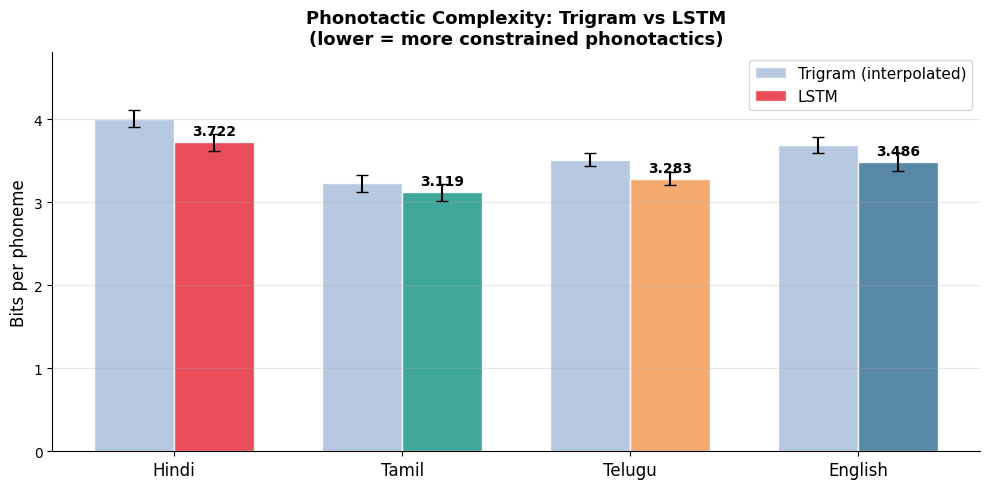

Saved: fig5_ngram_vs_lstm.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

x         = np.arange(len(LANGUAGES))
width     = 0.35
ngram_means = [np.mean(ngram_results[lid]) for lid in LANGUAGES]
lstm_means  = [np.mean(results_lstm[lid])  for lid in LANGUAGES]
ngram_stds  = [np.std(ngram_results[lid])  for lid in LANGUAGES]
lstm_stds   = [np.std(results_lstm[lid])   for lid in LANGUAGES]

bars1 = ax.bar(x - width/2, ngram_means, width, yerr=ngram_stds,
               label="Trigram (interpolated)", color="#B0C4DE",
               edgecolor="white", capsize=4, alpha=0.9)

bars2 = ax.bar(x + width/2, lstm_means, width, yerr=lstm_stds,
               label="LSTM", color=[LANG_COLORS[l] for l in LANGUAGES],
               edgecolor="white", capsize=4, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels([LANG_NAMES[l] for l in LANGUAGES], fontsize=12)
ax.set_ylabel("Bits per phoneme", fontsize=12)
ax.set_title("Phonotactic Complexity: Trigram vs LSTM\n(lower = more constrained phonotactics)",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(ngram_means) + 0.8)

# Annotate LSTM bars with values
for bar, val in zip(bars2, lstm_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig5_ngram_vs_lstm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_ngram_vs_lstm.png")

In [14]:
with open("/kaggle/working/lstm_results.json", "w") as f:
    json.dump(results_lstm, f, indent=2)

comparison_df.to_csv("/kaggle/working/table3_ngram_vs_lstm.csv")

print("Saved:")
print("  /kaggle/working/lstm_results.json")
print("  /kaggle/working/table3_ngram_vs_lstm.csv")
print("  /kaggle/working/fig5_ngram_vs_lstm.png")
print()

Saved:
  /kaggle/working/lstm_results.json
  /kaggle/working/table3_ngram_vs_lstm.csv
  /kaggle/working/fig5_ngram_vs_lstm.png

